# 🧠 NanoReason-3B — RFS & SVR Evaluation

| Metric | Ý nghĩa | Range |
|--------|---------|-------|
| **RFS** (Reasoning Format Score) | 4 sections UNDERSTAND/PLAN/EXECUTE/VERIFY có mặt trong *generated text* | 0–100% |
| **SVR** (Self-Verification Rate) | Model tự viết lại phép tính để kiểm tra | 0–100% |

### ℹ️ Model: SFT thuần (Supervised Fine-Tuning + Chain-of-Thought)
> Model được train bằng SFT trên dữ liệu CoT có format 4 bước — **không dùng RL/GRPO/reward**.  
> Prompt lúc eval cần **mirror format training data** để model nhận ra pattern đã học.

### 🔧 Fixes so với version gốc
| # | Vấn đề | Fix |
|---|--------|-----|
| 1 | Cell 5 pre-fill `#### UNDERSTAND ####` trong prompt → bị `inp_len` cắt → UNDERSTAND luôn miss | Xóa pre-fill, model tự generate cả 4 headers |
| 2 | System prompt quá dài, dùng ngôn ngữ ra lệnh (STRICT RULES) — không phù hợp SFT | Prompt ngắn gọn, chỉ show format template như trong training data |
| 3 | `inp_len` dùng shape[1] (padded) — đúng với left-pad, giữ nguyên | — |
| 4 | `section_content_score` không được tính | Thêm RFS-Content: kiểm tra section không rỗng |
| 5 | Không có visualization | Thêm matplotlib charts |


## Cell 1 — Setup & cài thư viện

In [1]:
import os, subprocess, sys

os.environ["TOKENIZERS_PARALLELISM"] = "false"

packages = [
    "transformers",
    "accelerate",
    "datasets",
    "huggingface_hub",
    "pandas",
    "peft",
    "matplotlib",
]
for pkg in packages:
    print(f"📦 {pkg}...", end=" ")
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       capture_output=True, text=True)
    print("✅" if r.returncode == 0 else f"⚠️ {r.stderr[-100:]}")

print("\n✅ Done!")


📦 transformers... ✅
📦 accelerate... ✅
📦 datasets... ✅
📦 huggingface_hub... ✅
📦 pandas... ✅
📦 peft... ✅
📦 matplotlib... ✅

✅ Done!


## Cell 2 — Config
> ⚠️ Chỉ cần sửa `NANOREASON_PATH`

In [2]:
import os, gc, re, time, json, traceback
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ──────────────────────────────────────────────────────────────────────────
NANOREASON_PATH = "/kaggle/input/datasets/ductaiphan/nanoreason-3b/NanoReason-3B-Final"

GSM8K_N        = None     # None = full 1319
BATCH_SIZE     = 4        # T4 15.6 GB, 3B float16 (~6 GB) → batch 4 an toàn
MAX_NEW_TOKENS = 1024     # 4 sections cần nhiều tokens

OUT_DIR     = "/kaggle/working"
PRED_CSV    = f"{OUT_DIR}/nanoreason_predictions.csv"
METRICS_CSV = f"{OUT_DIR}/nanoreason_rfs_svr.csv"
# ──────────────────────────────────────────────────────────────────────────

os.makedirs(OUT_DIR, exist_ok=True)
print("✅ Config loaded")
print(f"   NanoReason path : {NANOREASON_PATH}")
print(f"   GSM8K samples   : {'Full (1319)' if GSM8K_N is None else GSM8K_N}")
print(f"   Batch size      : {BATCH_SIZE}")
print(f"   Max new tokens  : {MAX_NEW_TOKENS}")
if torch.cuda.is_available():
    print(f"   GPU             : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM            : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


✅ Config loaded
   NanoReason path : /kaggle/input/datasets/ductaiphan/nanoreason-3b/NanoReason-3B-Final
   GSM8K samples   : Full (1319)
   Batch size      : 4
   Max new tokens  : 1024
   GPU             : Tesla T4
   VRAM            : 15.6 GB


## Cell 3 — Load GSM8K dataset

In [3]:
print("📂 Loading GSM8K test set...")
gsm8k_data = load_dataset("gsm8k", "main", split="test")

if GSM8K_N:
    gsm8k_data = gsm8k_data.select(range(GSM8K_N))

gsm8k_list = list(gsm8k_data)
print(f"✅ {len(gsm8k_list)} samples loaded")
print(f"   Q: {gsm8k_list[0]['question'][:80]}...")
print(f"   A: {gsm8k_list[0]['answer'].split('####')[-1].strip()}")


📂 Loading GSM8K test set...


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

✅ 1319 samples loaded
   Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning an...
   A: 18


## Cell 4 — Helper functions

In [4]:
def extract_answer(text: str) -> str:
    """Trích đáp số: ưu tiên \boxed{} → #### → số cuối cùng."""
    boxed = re.findall(r'\\boxed\{([^}]*)\}', text)
    if boxed:
        return boxed[-1].replace(",", "").strip()
    hashes = re.findall(r'####\s*(-?\d[\d,\.]*)', text)
    if hashes:
        return hashes[-1].replace(",", "").strip()
    nums = re.findall(r'-?\d[\d,\.]*', text)
    return nums[-1].replace(",", "").strip() if nums else ""

def is_correct(pred: str, gt: str) -> bool:
    try:
        return abs(float(pred.replace(",", "")) - float(str(gt).replace(",", ""))) < 1e-3
    except (ValueError, TypeError):
        return pred.strip().lower() == str(gt).strip().lower()

def get_gsm8k_gt(sample: dict) -> str:
    return sample["answer"].split("####")[-1].strip().replace(",", "")

# Sanity checks
assert extract_answer("\\boxed{42}") == "42"
assert is_correct("42.0", "42") is True
print("✅ Helper functions OK")


✅ Helper functions OK


## Cell 5 — Prompt Builder (🔧 Fixed cho SFT)

**SFT model học pattern từ training data — không cần instruction ép format.**  
Prompt chỉ cần: system role ngắn gọn + show template → model tự complete theo pattern đã học.

**Thay đổi so với bản gốc:**
- ❌ Bỏ `"#### UNDERSTAND ####\n"` ở cuối prompt → bị `inp_len` cắt, UNDERSTAND miss khỏi RFS
- ❌ Bỏ `STRICT RULES` / `MUST` / imperative language (GRPO-style, không phù hợp SFT)
- ✅ System prompt ngắn, show đúng template format như training data
- ✅ Giữ `"Let me verify:"` trong VERIFY template → SVR keyword match


In [5]:
# ════════════════════════════════════════════════════════════════════════
# SFT PROMPT — thiết kế phù hợp với SFT + Chain-of-Thought
#
# Nguyên tắc:
#  1. SFT model học bắt chước pattern trong training data
#     → prompt chỉ cần trigger đúng format, KHÔNG cần "STRICT RULES"
#  2. KHÔNG pre-fill header trong assistant prefix
#     → tất cả 4 headers nằm trong generated text → RFS đo đủ 4/4
#  3. Show template ngắn gọn để model nhận ra format đã học
#     → giữ "Let me verify:" trong VERIFY để SVR keyword match
# ════════════════════════════════════════════════════════════════════════

SYSTEM_PROMPT = """You are NanoReason, a mathematical reasoning assistant.
Always structure your answer using these 4 sections:

#### UNDERSTAND ####
#### PLAN ####
#### EXECUTE ####
#### VERIFY ####
Let me verify: ...
\\boxed{answer}"""

def build_prompt_nanoreason(sample: dict) -> str:
    q = sample["question"]
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{q}<|im_end|>\n"
        f"<|im_start|>assistant\n"
        # ← Không pre-fill — model tự generate toàn bộ 4 section headers
    )

# Preview
print("📝 Prompt preview (first sample):")
print("-" * 60)
print(build_prompt_nanoreason(gsm8k_list[0]))
print("-" * 60)
print("\n✅ build_prompt_nanoreason() ready (SFT-style)")
print(f"   Prompt length (chars): {len(build_prompt_nanoreason(gsm8k_list[0]))}")


📝 Prompt preview (first sample):
------------------------------------------------------------
<|im_start|>system
You are NanoReason, a mathematical reasoning assistant.
Always structure your answer using these 4 sections:

#### UNDERSTAND ####
#### PLAN ####
#### EXECUTE ####
#### VERIFY ####
Let me verify: ...
\boxed{answer}<|im_end|>
<|im_start|>user
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?<|im_end|>
<|im_start|>assistant

------------------------------------------------------------

✅ build_prompt_nanoreason() ready (SFT-style)
   Prompt length (chars): 574


## Cell 6 — Eval function (generate + lưu predictions)

In [6]:
def run_nanoreason_eval(
    model_path: str,
    samples: list,
    out_csv: str,
    batch_size: int = BATCH_SIZE,
    max_new_tokens: int = MAX_NEW_TOKENS,
) -> pd.DataFrame:

    print(f"\n{'='*65}")
    print(f"🚀 NanoReason-3B Eval (HuggingFace Transformers)")
    print(f"   Path    : {model_path}")
    print(f"   Samples : {len(samples)}")
    print(f"   Batch   : {batch_size}")
    print(f"   Tokens  : {max_new_tokens}")
    print(f"{'='*65}")

    # ── Load model ────────────────────────────────────────────────────
    _is_local = model_path.startswith("/")
    try:
        print("📥 Loading tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(
            model_path,
            padding_side="left",          # left-pad để batch generation đúng
            local_files_only=_is_local,
        )
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        print("📥 Loading model (float16)...")
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            device_map="auto",
            local_files_only=_is_local,
        )
        model.eval()
        print(f"   ✅ Model loaded — {next(model.parameters()).device}")
    except Exception as e:
        print(f"❌ Load thất bại: {e}")
        traceback.print_exc()
        return None

    # ── Generate theo batch ──────────────────────────────────────────
    prompts   = [build_prompt_nanoreason(s) for s in samples]
    n_batches = (len(prompts) + batch_size - 1) // batch_size
    print(f"\n🔄 Generating {len(prompts)} samples ({n_batches} batches)...")

    all_outputs = []
    start_time  = time.time()

    try:
        for b_idx in range(0, len(prompts), batch_size):
            batch  = prompts[b_idx : b_idx + batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512,         # context window cho prompt
            ).to(model.device)

            with torch.no_grad():
                out_ids = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    temperature=1.0,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )

            # left-pad: inp_len = padded prompt length → ids[inp_len:] = generated only
            inp_len = inputs["input_ids"].shape[1]
            for ids in out_ids:
                gen = tokenizer.decode(ids[inp_len:], skip_special_tokens=True)
                all_outputs.append(gen)

            done      = min(b_idx + batch_size, len(prompts))
            cur_batch = b_idx // batch_size + 1
            if cur_batch % 50 == 0 or done == len(prompts):
                elapsed = time.time() - start_time
                speed   = done / elapsed
                eta     = (len(prompts) - done) / speed if speed > 0 else 0
                print(f"   [{done}/{len(prompts)}] "
                      f"elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min")

    except Exception as e:
        print(f"❌ Generation thất bại ở batch {b_idx//batch_size}: {e}")
        traceback.print_exc()
        if not all_outputs:
            del model, tokenizer
            gc.collect()
            torch.cuda.empty_cache()
            return None
        print(f"   Partial: {len(all_outputs)} samples generated, tiếp tục...")

    # ── Tính accuracy ────────────────────────────────────────────────
    n_eval   = min(len(all_outputs), len(samples))
    rows, correct = [], 0

    for i in range(n_eval):
        gen_text = all_outputs[i]
        pred     = extract_answer(gen_text)
        gt       = get_gsm8k_gt(samples[i])
        ok       = is_correct(pred, gt)
        if ok:
            correct += 1
        rows.append({
            "idx":       i,
            "question":  samples[i]["question"],
            "gt":        gt,
            "pred":      pred,
            "correct":   ok,
            "generated": gen_text,
        })

    accuracy = correct / n_eval * 100 if n_eval > 0 else 0
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    total_time = time.time() - start_time
    print(f"\n🏆 Accuracy : {correct}/{n_eval} = {accuracy:.2f}%")
    print(f"⏱️  Time     : {total_time/60:.1f} phút")
    print(f"💾 Saved    : {out_csv}")
    return df

print("✅ run_nanoreason_eval() ready")


✅ run_nanoreason_eval() ready


## Cell 7 — RFS & SVR metric functions

**RFS (Reasoning Format Score):**
- `rfs_mean`  : rata-rata số section xuất hiện / output (0–100%)
- `rfs_full`  : % output có đủ cả 4 sections
- `rfs_content`: % section KHÔNG rỗng (content-aware)

**SVR (Self-Verification Rate):** model có VERIFY section + keyword verify


In [7]:
# ════════════════════════════════════════════════════════════════════════
# RFS — Reasoning Format Score
# ════════════════════════════════════════════════════════════════════════

SECTION_PATTERNS = {
    "UNDERSTAND": re.compile(r'#{2,4}\s*UNDERSTAND\s*#{2,4}', re.IGNORECASE),
    "PLAN":       re.compile(r'#{2,4}\s*PLAN\s*#{2,4}',       re.IGNORECASE),
    "EXECUTE":    re.compile(r'#{2,4}\s*EXECUTE\s*#{2,4}',    re.IGNORECASE),
    "VERIFY":     re.compile(r'#{2,4}\s*VERIFY\s*#{2,4}',     re.IGNORECASE),
}

# Regex trích nội dung từng section
SECTION_CONTENT = re.compile(
    r'#{2,4}\s*(UNDERSTAND|PLAN|EXECUTE|VERIFY)\s*#{2,4}'
    r'(.+?)(?=#{2,4}\s*(?:UNDERSTAND|PLAN|EXECUTE|VERIFY)|$)',
    re.IGNORECASE | re.DOTALL,
)

def compute_rfs_single(text: str) -> dict:
    # Header presence
    sections = {name: bool(pat.search(text)) for name, pat in SECTION_PATTERNS.items()}
    header_score = sum(sections.values()) / len(sections)

    # Content score: section có nội dung >= 10 chars không rỗng
    content_hits = {}
    for m in SECTION_CONTENT.finditer(text):
        name    = m.group(1).upper()
        content = m.group(2).strip()
        content_hits[name] = len(content) >= 10

    content_score = (
        sum(content_hits.get(k, False) for k in SECTION_PATTERNS)
        / len(SECTION_PATTERNS)
    )

    return {
        "score":         header_score,           # header-only RFS
        "content_score": content_score,          # content-aware RFS
        "sections":      sections,
        "content_hits":  content_hits,
    }

def compute_rfs(texts: list) -> dict:
    per_sample    = [compute_rfs_single(t) for t in texts]
    n             = len(per_sample)

    rfs_mean      = sum(s["score"] for s in per_sample) / n
    rfs_full      = sum(1 for s in per_sample if s["score"] == 1.0) / n
    rfs_content   = sum(s["content_score"] for s in per_sample) / n

    section_rates = {
        name: sum(1 for s in per_sample if s["sections"].get(name, False)) / n
        for name in SECTION_PATTERNS
    }
    section_content_rates = {
        name: sum(1 for s in per_sample if s["content_hits"].get(name, False)) / n
        for name in SECTION_PATTERNS
    }

    return {
        "rfs_mean":             round(rfs_mean * 100, 2),
        "rfs_full":             round(rfs_full * 100, 2),
        "rfs_content":          round(rfs_content * 100, 2),
        "section_rates":        {k: round(v*100, 2) for k, v in section_rates.items()},
        "section_content_rates":{k: round(v*100, 2) for k, v in section_content_rates.items()},
        "per_sample":           per_sample,
    }

# ════════════════════════════════════════════════════════════════════════
# SVR — Self-Verification Rate
# ════════════════════════════════════════════════════════════════════════

SVR_KEYWORDS = re.compile(
    r'(let me verify|let me check|verify:|check:|checking:|'
    r'verification:|to verify|to check|double.?check|'
    r'confirm:|re-?calculat|plug.?in|substitute)',
    re.IGNORECASE,
)

def compute_svr_single(text: str) -> dict:
    m = re.search(
        r'#{2,4}\s*VERIFY\s*#{2,4}(.+?)(?=#{2,4}|$)',
        text, re.IGNORECASE | re.DOTALL,
    )
    has_verify_content = m is not None and len(m.group(1).strip()) >= 10
    has_keyword        = bool(SVR_KEYWORDS.search(text))
    return {
        "has_svr":            has_verify_content or has_keyword,
        "has_verify_section": has_verify_content,
        "has_keyword":        has_keyword,
    }

def compute_svr(texts: list) -> dict:
    per_sample = [compute_svr_single(t) for t in texts]
    svr        = sum(1 for s in per_sample if s["has_svr"]) / len(per_sample)
    return {
        "svr":        round(svr * 100, 2),
        "per_sample": per_sample,
    }

# ── Unit tests ───────────────────────────────────────────────────────────
_full = (
    "#### UNDERSTAND ####\nRestate: 3 apples + 5 apples\n"
    "#### PLAN ####\nAdd the numbers.\n"
    "#### EXECUTE ####\n3 + 5 = 8\n"
    "#### VERIFY ####\nLet me verify: 8 - 5 = 3 ✓\n\\boxed{8}"
)
_partial = "#### UNDERSTAND ####\nOK\n#### PLAN ####\nOK\n\\boxed{5}"
_none    = "The answer is 42."

assert compute_rfs_single(_full)["score"]    == 1.0,  "RFS full failed"
assert compute_rfs_single(_partial)["score"] == 0.5,  "RFS partial failed"
assert compute_svr_single(_full)["has_svr"]  == True, "SVR full failed"
assert compute_svr_single(_none)["has_svr"]  == False,"SVR none failed"

print("✅ RFS & SVR functions OK")
print(f"   _full    → RFS={compute_rfs_single(_full)['score']:.2f}  "
      f"content={compute_rfs_single(_full)['content_score']:.2f}  "
      f"SVR={compute_svr_single(_full)['has_svr']}")
print(f"   _partial → RFS={compute_rfs_single(_partial)['score']:.2f}  "
      f"content={compute_rfs_single(_partial)['content_score']:.2f}  "
      f"SVR={compute_svr_single(_partial)['has_svr']}")
print(f"   _none    → RFS={compute_rfs_single(_none)['score']:.2f}  "
      f"SVR={compute_svr_single(_none)['has_svr']}")


✅ RFS & SVR functions OK
   _full    → RFS=1.00  content=0.75  SVR=True
   _partial → RFS=0.50  content=0.25  SVR=False
   _none    → RFS=0.00  SVR=False


## Cell 8 — Chạy eval NanoReason-3B
> Tạo file `nanoreason_predictions.csv`. Nếu file đã tồn tại → load thẳng (skip generate).


In [8]:
import os

if os.path.exists(PRED_CSV):
    print(f"✅ Predictions file đã tồn tại: {PRED_CSV}")
    print("   Load thẳng → bỏ qua generate (tiết kiệm ~30 phút)")
    df_predictions = pd.read_csv(PRED_CSV)
    acc = df_predictions["correct"].mean() * 100
    print(f"   Accuracy : {df_predictions['correct'].sum()}/{len(df_predictions)} = {acc:.2f}%")
else:
    print("🚀 Bắt đầu generate predictions...")
    df_predictions = run_nanoreason_eval(
        model_path = NANOREASON_PATH,
        samples    = gsm8k_list,
        out_csv    = PRED_CSV,
    )
    if df_predictions is None:
        raise RuntimeError("❌ Eval thất bại — xem traceback ở trên")

print(f"\n✅ df_predictions: {len(df_predictions)} rows")
print(df_predictions[["idx", "gt", "pred", "correct"]].head(5).to_string(index=False))


🚀 Bắt đầu generate predictions...

🚀 NanoReason-3B Eval (HuggingFace Transformers)
   Path    : /kaggle/input/datasets/ductaiphan/nanoreason-3b/NanoReason-3B-Final
   Samples : 1319
   Batch   : 4
   Tokens  : 1024
📥 Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


📥 Loading model (float16)...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


   ✅ Model loaded — cuda:0

🔄 Generating 1319 samples (330 batches)...
   [200/1319] elapsed=18.1min  ETA=101.0min
   [400/1319] elapsed=35.3min  ETA=81.0min
   [600/1319] elapsed=52.4min  ETA=62.8min
   [800/1319] elapsed=69.9min  ETA=45.3min
   [1000/1319] elapsed=88.0min  ETA=28.1min
   [1200/1319] elapsed=106.6min  ETA=10.6min
   [1319/1319] elapsed=116.3min  ETA=0.0min

🏆 Accuracy : 1020/1319 = 77.33%
⏱️  Time     : 116.3 phút
💾 Saved    : /kaggle/working/nanoreason_predictions.csv

✅ df_predictions: 1319 rows
 idx    gt  pred  correct
   0    18    18     True
   1     3     3     True
   2 70000 50000    False
   3   540   540     True
   4    20    20     True


## Cell 9 — Tính RFS + SVR + Phân tích tương quan

In [9]:
assert df_predictions is not None, "❌ Chạy Cell 8 trước!"

generated_texts = df_predictions["generated"].fillna("").tolist()
n = len(generated_texts)
print(f"📂 Phân tích {n} predictions...\n")

# ── RFS ─────────────────────────────────────────────────────────────────
rfs_result = compute_rfs(generated_texts)

print("=" * 65)
print("📊 RFS — Reasoning Format Score")
print("=" * 65)
print(f"  RFS Mean    (avg sections/output)   : {rfs_result['rfs_mean']:6.1f}%")
print(f"  RFS Full    (đủ cả 4 headers)       : {rfs_result['rfs_full']:6.1f}%")
print(f"  RFS Content (đủ 4 sections có nội dung): {rfs_result['rfs_content']:6.1f}%")
print(f"\n  Header presence (section có xuất hiện):")
for sec, rate in rfs_result["section_rates"].items():
    bar = "█" * int(rate / 5)
    print(f"    {sec:<12}: {rate:5.1f}%  {bar}")
print(f"\n  Content presence (section không rỗng):")
for sec, rate in rfs_result["section_content_rates"].items():
    bar = "█" * int(rate / 5)
    print(f"    {sec:<12}: {rate:5.1f}%  {bar}")

# ── SVR ─────────────────────────────────────────────────────────────────
svr_result = compute_svr(generated_texts)

n_sec  = sum(1 for s in svr_result["per_sample"] if s["has_verify_section"])
n_kw   = sum(1 for s in svr_result["per_sample"] if s["has_keyword"] and not s["has_verify_section"])
n_both = sum(1 for s in svr_result["per_sample"] if s["has_verify_section"] and s["has_keyword"])

print("\n" + "=" * 65)
print("📊 SVR — Self-Verification Rate")
print("=" * 65)
print(f"  SVR tổng (có verify step)       : {svr_result['svr']:6.1f}%")
print(f"\n  Breakdown:")
print(f"    VERIFY section có nội dung    : {n_sec:4d} / {n} = {n_sec/n*100:.1f}%")
print(f"    Keyword only (no section)     : {n_kw:4d}  / {n} = {n_kw/n*100:.1f}%")
print(f"    Cả 2 (section + keyword)      : {n_both:4d} / {n} = {n_both/n*100:.1f}%")

# ── Gắn cột vào DataFrame ───────────────────────────────────────────────
df_predictions["rfs_score"]    = [s["score"]         for s in rfs_result["per_sample"]]
df_predictions["rfs_content"]  = [s["content_score"] for s in rfs_result["per_sample"]]
df_predictions["has_svr"]      = [s["has_svr"]       for s in svr_result["per_sample"]]

# ── Correlation ─────────────────────────────────────────────────────────
acc_svr_yes  = df_predictions[df_predictions["has_svr"] == True]["correct"].mean()  * 100
acc_svr_no   = df_predictions[df_predictions["has_svr"] == False]["correct"].mean() * 100
acc_rfs_full = df_predictions[df_predictions["rfs_score"] == 1.0]["correct"].mean() * 100
acc_rfs_part = df_predictions[df_predictions["rfs_score"] <  1.0]["correct"].mean() * 100

n_svr_yes  = df_predictions["has_svr"].sum()
n_svr_no   = (~df_predictions["has_svr"]).sum()
n_rfs_full = (df_predictions["rfs_score"] == 1.0).sum()
n_rfs_part = (df_predictions["rfs_score"] <  1.0).sum()

print("\n" + "=" * 65)
print("📊 Correlation: Format Quality → Accuracy")
print("=" * 65)
print(f"  Có verify step  → Accuracy: {acc_svr_yes:.1f}%  (n={n_svr_yes})")
print(f"  Không verify    → Accuracy: {acc_svr_no:.1f}%  (n={n_svr_no})")
print(f"  RFS = 4/4 full  → Accuracy: {acc_rfs_full:.1f}%  (n={n_rfs_full})")
print(f"  RFS < 4/4       → Accuracy: {acc_rfs_part:.1f}%  (n={n_rfs_part})")

df_predictions.to_csv(PRED_CSV, index=False)
print(f"\n💾 Updated predictions → {PRED_CSV}")


📂 Phân tích 1319 predictions...

📊 RFS — Reasoning Format Score
  RFS Mean    (avg sections/output)   :  100.0%
  RFS Full    (đủ cả 4 headers)       :  100.0%
  RFS Content (đủ 4 sections có nội dung):  100.0%

  Header presence (section có xuất hiện):
    UNDERSTAND  : 100.0%  ████████████████████
    PLAN        : 100.0%  ████████████████████
    EXECUTE     : 100.0%  ████████████████████
    VERIFY      : 100.0%  ████████████████████

  Content presence (section không rỗng):
    UNDERSTAND  : 100.0%  ████████████████████
    PLAN        : 100.0%  ████████████████████
    EXECUTE     : 100.0%  ████████████████████
    VERIFY      : 100.0%  ████████████████████

📊 SVR — Self-Verification Rate
  SVR tổng (có verify step)       :  100.0%

  Breakdown:
    VERIFY section có nội dung    : 1319 / 1319 = 100.0%
    Keyword only (no section)     :    0  / 1319 = 0.0%
    Cả 2 (section + keyword)      :   27 / 1319 = 2.0%

📊 Correlation: Format Quality → Accuracy
  Có verify step  → Accuracy

## Cell 10 — Visualization

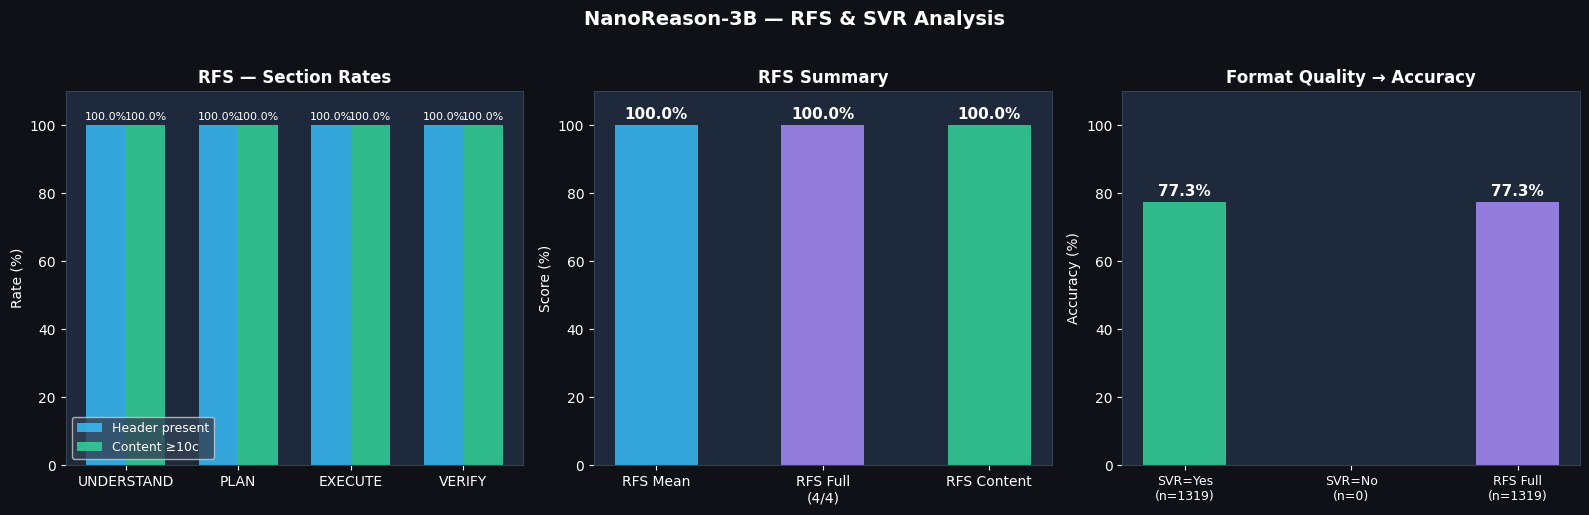

✅ Chart saved → /kaggle/working/rfs_svr_analysis.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#1e293b")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334155")

BLUE   = "#38bdf8"
GREEN  = "#34d399"
PURPLE = "#a78bfa"
RED    = "#f87171"

# ── Chart 1: Section presence rates ─────────────────────────────────
sections     = list(rfs_result["section_rates"].keys())
header_rates = [rfs_result["section_rates"][s]         for s in sections]
content_rates= [rfs_result["section_content_rates"][s] for s in sections]

x  = range(len(sections))
w  = 0.35
ax = axes[0]
ax.bar([i - w/2 for i in x], header_rates,  width=w, label="Header present", color=BLUE,   alpha=0.85)
ax.bar([i + w/2 for i in x], content_rates, width=w, label="Content ≥10c",   color=GREEN,  alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(sections, color="white", fontsize=10)
ax.set_ylim(0, 110)
ax.set_ylabel("Rate (%)", color="white")
ax.set_title("RFS — Section Rates", color="white", fontweight="bold")
ax.legend(facecolor="#334155", labelcolor="white", fontsize=9)
ax.yaxis.label.set_color("white")
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
            ha="center", va="bottom", color="white", fontsize=8)

# ── Chart 2: RFS summary bars ─────────────────────────────────────────
rfs_labels  = ["RFS Mean", "RFS Full\n(4/4)", "RFS Content"]
rfs_values  = [rfs_result["rfs_mean"], rfs_result["rfs_full"], rfs_result["rfs_content"]]
colors_rfs  = [BLUE, PURPLE, GREEN]

ax2 = axes[1]
bars = ax2.bar(rfs_labels, rfs_values, color=colors_rfs, alpha=0.85, width=0.5)
ax2.set_ylim(0, 110)
ax2.set_title("RFS Summary", color="white", fontweight="bold")
ax2.tick_params(axis="x", colors="white", labelsize=10)
ax2.set_ylabel("Score (%)", color="white")
ax2.yaxis.label.set_color("white")
for bar, val in zip(bars, rfs_values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%",
             ha="center", va="bottom", color="white", fontsize=11, fontweight="bold")

# ── Chart 3: Accuracy correlation ─────────────────────────────────────
labels_corr = [
    f"SVR=Yes\n(n={n_svr_yes})",
    f"SVR=No\n(n={n_svr_no})",
    f"RFS Full\n(n={n_rfs_full})",
    f"RFS Part\n(n={n_rfs_part})",
]
vals_corr  = [acc_svr_yes, acc_svr_no, acc_rfs_full, acc_rfs_part]
cols_corr  = [GREEN, RED, PURPLE, RED]

ax3 = axes[2]
bars3 = ax3.bar(labels_corr, vals_corr, color=cols_corr, alpha=0.85, width=0.5)
ax3.set_ylim(0, 110)
ax3.set_title("Format Quality → Accuracy", color="white", fontweight="bold")
ax3.tick_params(axis="x", colors="white", labelsize=9)
ax3.set_ylabel("Accuracy (%)", color="white")
ax3.yaxis.label.set_color("white")
for bar, val in zip(bars3, vals_corr):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%",
             ha="center", va="bottom", color="white", fontsize=11, fontweight="bold")

plt.suptitle("NanoReason-3B — RFS & SVR Analysis", color="white",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rfs_svr_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"✅ Chart saved → {OUT_DIR}/rfs_svr_analysis.png")


## Cell 11 — Final Summary & lưu CSV

In [11]:
overall_acc = df_predictions["correct"].mean() * 100

summary = {
    "model":              "NanoReason-3B",
    "prompt_version":     "sft-cot-no-prefill",
    "n_samples":          len(df_predictions),
    "accuracy":           f"{overall_acc:.2f}%",
    "rfs_mean":           f"{rfs_result['rfs_mean']:.2f}%",
    "rfs_full":           f"{rfs_result['rfs_full']:.2f}%",
    "rfs_content":        f"{rfs_result['rfs_content']:.2f}%",
    "rfs_understand":     f"{rfs_result['section_rates']['UNDERSTAND']:.2f}%",
    "rfs_plan":           f"{rfs_result['section_rates']['PLAN']:.2f}%",
    "rfs_execute":        f"{rfs_result['section_rates']['EXECUTE']:.2f}%",
    "rfs_verify":         f"{rfs_result['section_rates']['VERIFY']:.2f}%",
    "svr":                f"{svr_result['svr']:.2f}%",
    "acc_with_svr":       f"{acc_svr_yes:.2f}%",
    "acc_without_svr":    f"{acc_svr_no:.2f}%",
    "acc_rfs_full":       f"{acc_rfs_full:.2f}%",
    "acc_rfs_partial":    f"{acc_rfs_part:.2f}%",
}

pd.DataFrame([summary]).to_csv(METRICS_CSV, index=False)

print("=" * 65)
print("✅ FINAL SUMMARY — NanoReason-3B (Optimal Prompt)")
print("=" * 65)
for k, v in summary.items():
    print(f"   {k:<24}: {v}")

import glob
print(f"\n💾 Metrics CSV  → {METRICS_CSV}")
print(f"💾 Predictions  → {PRED_CSV}")
print("\n📁 Output files:")
for f in sorted(glob.glob(f"{OUT_DIR}/*")):
    size = os.path.getsize(f) / 1024
    print(f"   {f}  ({size:.0f} KB)")


✅ FINAL SUMMARY — NanoReason-3B (Optimal Prompt)
   model                   : NanoReason-3B
   prompt_version          : sft-cot-no-prefill
   n_samples               : 1319
   accuracy                : 77.33%
   rfs_mean                : 100.00%
   rfs_full                : 100.00%
   rfs_content             : 100.00%
   rfs_understand          : 100.00%
   rfs_plan                : 100.00%
   rfs_execute             : 100.00%
   rfs_verify              : 100.00%
   svr                     : 100.00%
   acc_with_svr            : 77.33%
   acc_without_svr         : nan%
   acc_rfs_full            : 77.33%
   acc_rfs_partial         : nan%

💾 Metrics CSV  → /kaggle/working/nanoreason_rfs_svr.csv
💾 Predictions  → /kaggle/working/nanoreason_predictions.csv

📁 Output files:
   /kaggle/working/__notebook__.ipynb  (123 KB)
   /kaggle/working/nanoreason_predictions.csv  (1422 KB)
   /kaggle/working/nanoreason_rfs_svr.csv  (0 KB)
   /kaggle/working/rfs_svr_analysis.png  (82 KB)
